## 🍕 2015年度披萨连锁店销售数据分析报告

1.1 项目初衷与数据来源

本项目源于个人的浓厚兴趣。在浏览 KaggleHub 时，我发现了这份关于 2015 年披萨店销售的数据集，这份数据包含了近 5 万条真实的交易记录

1.2 分析目标与三大维度

为了有条理地拆解这份数据，我设定了三个不同的视角来进行探索，试图模拟在真实经营中可能遇到的核心问题：

视角一：消费者体验与智能推荐（C端）
想解决的问题：如果我是 APP 开发者，我该如何根据销量和“性价比”给顾客推荐披萨？
核心目标：通过爆款榜单吸引流量，并利用“购物篮分析”挖掘最适合搭配销售的黄金组合。

视角二：门店运营与资源调度（B端）
想解决的问题：如果我是店长，我该在什么时候多招人手？每天早上该揉多少个不同尺寸的面团？
核心目标：识别订单的潮汐高峰时段，并预测核心配料的消耗量以减少浪费。

视角三：公司经营与定价策略（管理层）
想解决的问题：如果我是老板，涨价会影响生意吗？哪款披萨才是真正的“赚钱利器”？
核心目标：研究价格对销量的影响（需求弹性），并利用盈利矩阵分析各产品的战略贡献度。

# 数据说明

字段名	说明
pizza_id	可供订购的比萨ID
order_id	订单ID
pizza_name_id	披萨名称ID
quantity	订单中披萨的数量
order_date	下单日期
order_time	下单时间
unit_price	该订单的披萨单价
total_price	该订单的披萨总价
pizza_size	披萨的大小：小号、中号、大号
pizza_category	披萨的类别：素食、非素食等
pizza_ingredients	制作披萨的配料
pizza_name	披萨的名称


# 1. phyton库导入及数据读取
因为数据的发现源头是在kagglehub网站（https://www.kaggle.com/datasets/nextmillionaire/pizza-sales-dataset/data）上，可以按照网站的使用方法下载数据集，在这之前需要让环节支持并且调用kagglehub

In [ ]:
!pip install kagglehub

在这之后我稍微整理了一下所有要用到的一些功能的import，并且让这个文件正确的下载

In [ ]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

import kagglehub
# Download latest version
path = kagglehub.dataset_download("nextmillionaire/pizza-sales-dataset")
print("Path to dataset files:", path)


Path to dataset files: /Users/surinlopez/.cache/kagglehub/datasets/nextmillionaire/pizza-sales-dataset/versions/1


当下载好了文件后我们按照正常的逻辑开始进行确认，是否成功的下载了，并且在这个同时数据并没有出现乱码，预览数据前五行给我一个大概的对数据的了解

In [ ]:
# 1. 查看下载文件夹里有哪些文件
files = os.listdir(path)
print(f"文件夹里的文件有: {files}")

# 2. 自动找到里面以 .csv 结尾的数据表
csv_file = [f for f in files if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)
print(f"准备读取的文件路径是: {file_path}")

# 3. 使用 pandas 读取这个 csv 文件
df = pd.read_csv(file_path)

# 4. 预览数据的前 5 行，看看真实的字段！
print("\n=== 数据加载成功！前 5 行预览 ===")
display(df.head())

文件夹里的文件有: ['pizza_sales.csv']
准备读取的文件路径是: /Users/surinlopez/.cache/kagglehub/datasets/nextmillionaire/pizza-sales-dataset/versions/1/pizza_sales.csv

=== 数据加载成功！前 5 行预览 ===


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1.0,1.0,hawaiian_m,1.0,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2.0,2.0,classic_dlx_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3.0,2.0,five_cheese_l,1.0,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4.0,2.0,ital_supr_l,1.0,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5.0,2.0,mexicana_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


# 2. 数据的特征提取和清洗
拿到数据还是比较模糊，对整体需要进行一个了解并且在使用数据的时候，我们首先明确数据的基本盘大小，利用统计学方法（如分位数与 IQR 法则）侦测极端值，在ai辅助下它还推荐我对特征研究缺失值、重复值、逻辑一致性

In [ ]:
# === 1. 查看数据基本盘 ===
print("=== 1. 数据总量概览 ===")
print(f"总订单记录数: {len(df)} 条")
print(f"数据特征维度: {df.shape[1]} 列\n")

=== 1. 数据总量概览 ===
总订单记录数: 48620 条
数据特征维度: 12 列



In [ ]:
# === 2. 探查【销量】的特异值 ===
print("=== 2. 销量 (Quantity) 特异值探查 ===")
quantity_counts = df['quantity'].value_counts().sort_index()
display(quantity_counts)

=== 2. 销量 (Quantity) 特异值探查 ===


quantity
1.0    47693
2.0      903
3.0       21
4.0        3
Name: count, dtype: int64

In [ ]:
# === 3. 探查【价格】的特异值 (经济学 IQR 法则) ===
print("\n=== 3. 价格 (Unit Price) 异常值侦测 (IQR 箱线图法则) ===")

# 计算第一四分位数(Q1) 和 第三四分位数(Q3)
Q1 = df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)
IQR = Q3 - Q1

# 定义异常值的上下界 (通常使用 1.5 倍的 IQR)
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# 筛选出超出边界的特异值
price_outliers = df[(df['unit_price'] > upper_bound) | (df['unit_price'] < lower_bound)]

print(f"统计学正常价格区间: {lower_bound:.2f} 元 到 {upper_bound:.2f} 元")
print(f"发现 {len(price_outliers)} 条价格异常记录。")

# 展示最贵的 5 个“特异”披萨
if len(price_outliers) > 0:
    print("价格最高的极端特异值前 5 名:")
    display(price_outliers.sort_values(by='unit_price', ascending=False).head(5))
else:
    print("未发现严重偏离区间的价格异常值。")


=== 3. 价格 (Unit Price) 异常值侦测 (IQR 箱线图法则) ===
统计学正常价格区间: 1.50 元 到 31.50 元
发现 28 条价格异常记录。
价格最高的极端特异值前 5 名:


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
3447,3448.0,1528.0,the_greek_xxl,1.0,26-01-2015,15:24:38,35.95,35.95,XXL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza
3563,3564.0,1581.0,the_greek_xxl,1.0,27-01-2015,16:28:38,35.95,35.95,XXL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza
43040,43041.0,18919.0,the_greek_xxl,1.0,19-11-2015,16:58:26,35.95,35.95,XXL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza
42717,42718.0,18789.0,the_greek_xxl,1.0,17-11-2015,11:23:51,35.95,35.95,XXL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza
41182,41183.0,18139.0,the_greek_xxl,1.0,5/11/2015,20:28:52,35.95,35.95,XXL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza


In [ ]:
#缺失值統計
print("=== 缺失值檢查 ===")
print(df.isnull().sum())

=== 缺失值檢查 ===
pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64


In [ ]:
#重復值檢查
duplicate_count = df.duplicated().sum()
print(f"\n=== 重復值檢查 ===\n發現重復行數: {duplicate_count}")


=== 重復值檢查 ===
發現重復行數: 0


In [ ]:
# --- 1. 从原始 ID 中提取基础信息 ---
# 提取尺寸（如 S, M, L）并转大写
df['pizza_size'] = df['pizza_name_id'].str.split('_').str[-1].str.upper()
# 提取披萨名称（去除结尾的尺寸后缀）
df['pizza_base_name'] = df['pizza_name_id'].str.rsplit('_', n=1).str[0]

# --- 2. 创建干净的数据集副本 (df_clean) ---
# 选择分析所需的核心列
core_columns = ['pizza_base_name', 'pizza_size', 'unit_price', 'quantity', 'total_price', 'order_date', 'order_time']
df_clean = df[core_columns].copy() 

# --- 3. 日期与时间格式转换 (修复报错 & 特征提取) ---
# 解决日期格式混用问题
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'], format='mixed', dayfirst=True)

# 处理时间并提取“小时”和“星期”特征
temp_time = pd.to_datetime(df_clean['order_time'], format='%H:%M:%S')
df_clean['order_hour'] = temp_time.dt.hour
df_clean['order_time'] = temp_time.dt.time # 最终转回 time 对象
df_clean['day_of_week'] = df_clean['order_date'].dt.day_name()

# --- 4. 尺寸名称规范化 (Mapping) ---
size_map = {
    'S': 'Small (10")',
    'M': 'Medium (12")',
    'L': 'Large (14")',
    'XL': 'X-Large (16")',
    'XXL': 'XX-Large (18")'
}
df_clean['pizza_size_label'] = df_clean['pizza_size'].map(size_map)

# --- 5. 查看结果 ---
print("✅ 整合版清洗流程完成！所有报错已修复，特征已提取。")
display(df_clean.head())

✅ 整合版清洗流程完成！所有报错已修复，特征已提取。


,pizza_base_name,pizza_size,unit_price,quantity,total_price,order_date,order_time,order_hour,day_of_week,pizza_size_label
0,hawaiian,M,13.25,1.0,13.25,2015-01-01,11:38:36,11,Thursday,"Medium (12"")"
1,classic_dlx,M,16.00,1.0,16.00,2015-01-01,11:57:40,11,Thursday,"Medium (12"")"
2,five_cheese,L,18.50,1.0,18.50,2015-01-01,11:57:40,11,Thursday,"Large (14"")"
3,ital_supr,L,20.75,1.0,20.75,2015-01-01,11:57:40,11,Thursday,"Large (14"")"
4,mexicana,M,16.00,1.0,16.00,2015-01-01,11:57:40,11,Thursday,"Medium (12"")"


# 3.商业分析



### 数据清洗与核心 KPI 概览
在深入分析前，我们首先对原始数据进行格式标准化处理，并计算年度核心经营指标。

In [ ]:
# 1. 读取与标准化
df = pd.read_csv('pizza_sales.csv')

# 统一日期格式：使用 mixed 推断，dayfirst 确保日期正确
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S').dt.time
# 提取月份和星期用于后续分析
df['month'] = df['order_date'].dt.month
df['day_of_week'] = df['order_date'].dt.day_name()

# 2. 核心 KPI 计算
total_revenue = df['total_price'].sum()
total_orders = df['order_id'].nunique()
total_pizzas_sold = df['quantity'].sum()
aov = total_revenue / total_orders # 平均订单价值 (Average Order Value)
avg_pizza_per_order = total_pizzas_sold / total_orders

# 3. 打印年度成绩单
print("="*40)
print(f"💰 年度总营收 (Total Revenue): ${total_revenue:,.2f}")
print(f"📦 年度总订单量 (Total Orders): {total_orders:,}")
print(f"🍕 累计售出披萨 (Total Quantity): {total_pizzas_sold:,}")
print(f"💵 平均客单价 (AOV): ${aov:.2f}")
print(f"📊 每单平均购买个数: {avg_pizza_per_order:.2f}")
print("="*40)

# 4. 数据质量自检
print(f"\n✅ 数据清理完成：日期区间从 {df['order_date'].min().date()} 到 {df['order_date'].max().date()}")

💰 年度总营收 (Total Revenue): $817,860.05
📦 年度总订单量 (Total Orders): 21,350
🍕 累计售出披萨 (Total Quantity): 49,574.0
💵 平均客单价 (AOV): $38.31
📊 每单平均购买个数: 2.32

✅ 数据清理完成：日期区间从 2015-01-01 到 2015-12-31


### 阅读营收总趋势图

/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/2519436985.py:27: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/Users/surinlopez/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)


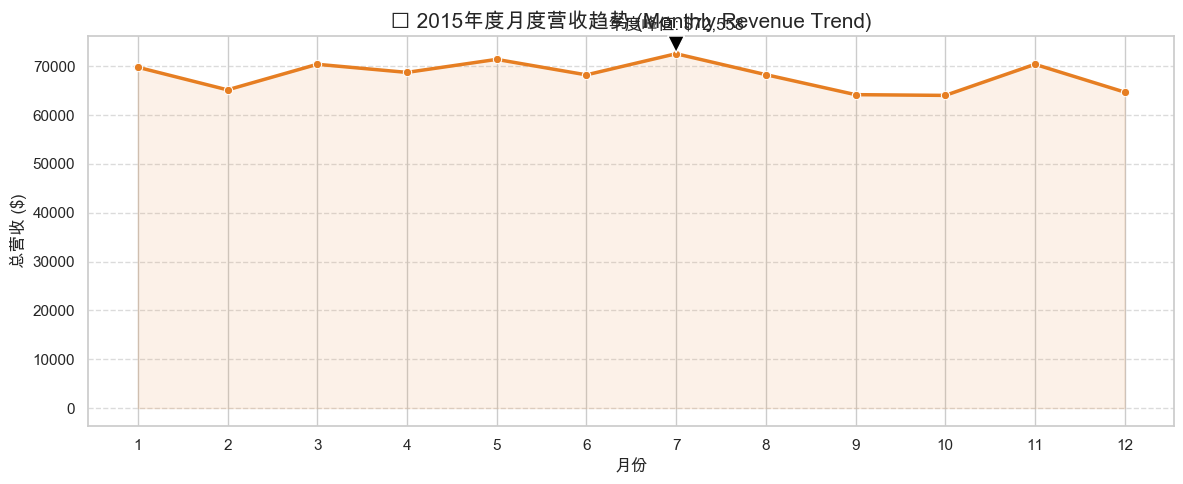

In [ ]:
# 计算月度趋势
monthly_sales = df.groupby('month')['total_price'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']

# 画折线图
sns.lineplot(data=monthly_sales, x='month', y='total_price', marker='o', linewidth=2.5, color='#e67e22')
plt.fill_between(monthly_sales['month'], monthly_sales['total_price'], alpha=0.1, color='#e67e22')

plt.title('📅 2015年度月度营收趋势 (Monthly Revenue Trend)', fontsize=15, fontweight='bold')
plt.xticks(range(1, 13))
plt.ylabel('总营收 ($)')
plt.xlabel('月份')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 标注最高点
max_val = monthly_sales['total_price'].max()
max_month = monthly_sales[monthly_sales['total_price'] == max_val]['month'].values[0]
plt.annotate(f'年度峰值: ${max_val:,.0f}', xy=(max_month, max_val), xytext=(max_month, max_val+5000),
             arrowprops=dict(facecolor='black', shrink=0.05), ha='center')

plt.tight_layout()
plt.show()

### 维度一：消费者体验与智能推荐 (C端分析)
本章旨在通过数据挖掘消费者偏好，为点餐 APP 的前端展示提供策略支持。核心业务目标为：打造具有吸引力的“爆款推荐位”，并通过“购物篮分析（Market Basket Analysis）”实现精准的连带销售（Cross-selling），从而有效提升客单价（AOV）。

#### 1. 首页流量分发：全店爆款与品类冠军推荐 (Top-Sellers Strategy)

本节针对点餐 APP 的新用户及习惯快速下单的复购用户，设计了“镇店之宝”推荐策略。在电商与餐饮平台的前端运营中，这被称为**“基于头部效应的流量分发机制”**。

**🔍 分析逻辑与算法：**
1. **聚合基础销量**：按 `pizza_name`（披萨名称）聚合汇总 `quantity`（销售总数），精准筛选出全店绝对销量 Top 5 的单品。
2. **构建垂直品类榜单**：引入 `pizza_category`（披萨品类）维度，分别计算“经典”、“素食”、“鸡肉”等不同垂类赛道下的销量冠军。
3. **双轨推荐机制**：为了避免单一销量维度的“赢者通吃”，我们采用双轨制。全店爆款用于承接大众流量，降低新客决策门槛；品类冠军用于满足特定口味偏好（如素食主义者）的个性化需求。

通过这种分层展示，我们能够在产品首页快速建立用户信任，极大缩短消费者的点餐决策链路，从而有效提升前端转化率（CVR）。

In [ ]:
print("=== 1. 前端推荐策略：全店爆款与品类冠军 ===")

# 1. 计算全店 Top 5 销量爆款
top_5_all = df.groupby('pizza_name')['quantity'].sum().sort_values(ascending=False).head(5)

# 2. 计算各个品类 (Category) 下的销量冠军
# 这样可以为不爱吃肉的人推荐素食冠军，为爱吃肉的推荐肉类冠军
category_champs = df.groupby(['pizza_category', 'pizza_name'])['quantity'].sum().reset_index()
category_champs = category_champs.sort_values(['pizza_category', 'quantity'], ascending=[True, False])
top_by_category = category_champs.drop_duplicates(subset=['pizza_category']).set_index('pizza_category')

print("\n🏆 【APP 首页推荐位】全店绝对爆款 Top 5：")
display(pd.DataFrame(top_5_all).rename(columns={'quantity': '总销量'}))

print("\n🥇 【分类导航推荐位】各品类销量冠军：")
display(top_by_category[['pizza_name', 'quantity']].rename(columns={'pizza_name':'冠军披萨', 'quantity': '该分类销量'}))

=== 1. 前端推荐策略：全店爆款与品类冠军 ===

🏆 【APP 首页推荐位】全店绝对爆款 Top 5：


,总销量
pizza_name,
The Classic Deluxe Pizza,2453.0
The Barbecue Chicken Pizza,2432.0
The Hawaiian Pizza,2422.0
The Pepperoni Pizza,2418.0
The Thai Chicken Pizza,2371.0



🥇 【分类导航推荐位】各品类销量冠军：


,冠军披萨,该分类销量
pizza_category,,
Chicken,The Barbecue Chicken Pizza,2432.0
Classic,The Classic Deluxe Pizza,2453.0
Supreme,The Sicilian Pizza,1938.0
Veggie,The Four Cheese Pizza,1902.0


=== 附：全店全品类披萨销量排行榜 (Top 10) ===


/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/528783414.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/528783414.py:32: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/Users/surinlopez/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)


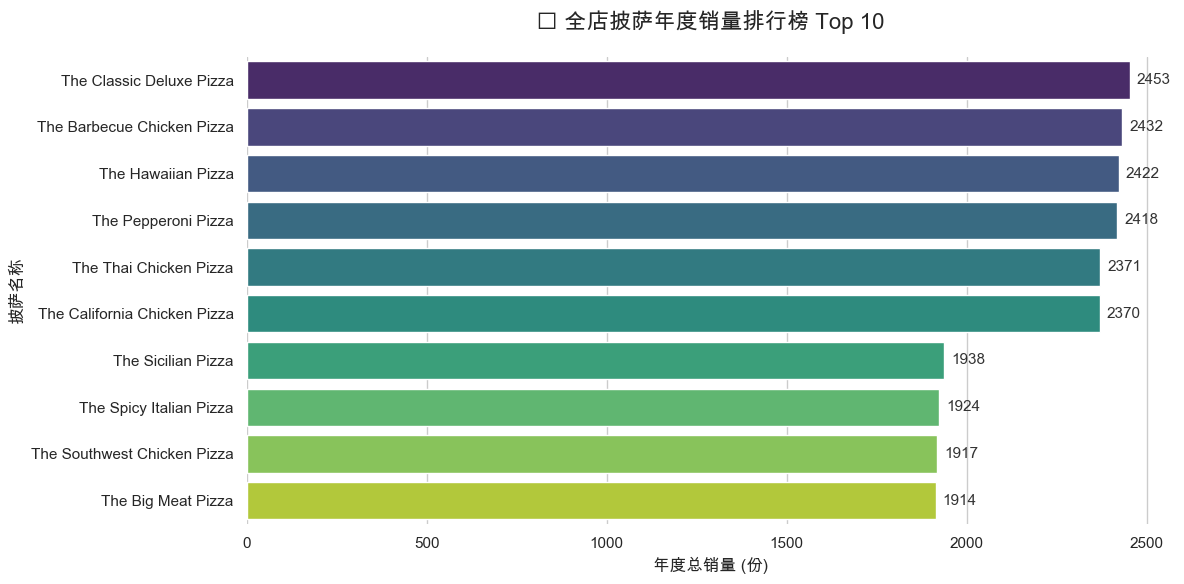

In [ ]:
print("=== 附：全店全品类披萨销量排行榜 (Top 10) ===")

# 【核心修复】：把 df_clean 换成了原始的 df，因为原表里才有完整的 pizza_name
top_10_pizza = df.groupby('pizza_name')['quantity'].sum().sort_values(ascending=False).head(10).reset_index()

# 设置高颜值画布
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 画水平柱状图
ax = sns.barplot(
    data=top_10_pizza, 
    x='quantity', 
    y='pizza_name', 
    palette='viridis' # 科技感渐变色板
)

# 在柱子末端添加具体数值 (赋值给 _ 防止输出烦人的 Text)
for container in ax.containers:
    _ = ax.bar_label(container, padding=5, fontsize=11, fontweight='bold', color='#333333')

plt.title('🏆 全店披萨年度销量排行榜 Top 10', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('年度总销量 (份)', fontsize=12)
plt.ylabel('披萨名称', fontsize=12)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

#### 总结 首页流量分发策略 (Top-Sellers)**
* 数据显示，少数几款核心披萨（如经典款与夏威夷款）贡献了极高的基础销量。建议在 APP/小程序 首页设置显眼的**“镇店之宝”**专区，直接减少新用户的决策时间，提高转化率。
* 同时，利用分类冠军榜单构建**“个性化导航”**（如：素食主义必点、肉食狂欢专区），满足不同圈层的长尾需求。

#### 2. 智能连带销售：“猜你喜欢”动态搭售策略 (Cross-Selling Strategy)

本节针对已进入购物车结算环节的用户，设计了自动化连带推荐策略。在数据挖掘与推荐系统领域，这被称为经典的**“购物篮分析（Market Basket Analysis）与关联规则挖掘”**。

**🔍 分析逻辑与算法：**
1. **清洗有效组合订单**：以 `order_id`（订单号）为唯一标识对数据进行分组，主动剔除仅包含单件商品的孤立订单，锁定具备“组合购买”特征的有效样本池。
2. **穷举共现频次 (Apriori 逻辑)**：利用数学组合算法（Combinations），对同一订单内的披萨单品进行两两无序配对，并全局遍历统计 `[披萨 A] 🤝 [披萨 B]` 组合在年度数据中共同出现的绝对频度。
3. **提取黄金搭档 (Top Pairs)**：依据共现频次降序排列，筛选出协同效应最强的 Top 5 最佳组合产品（例如：购买高价海鲜款的用户，高概率会顺手带一份平价素食款）。

通过这项算法挖掘，产品端可实现从“人找货”到“货找人”的智能跃迁。将其作为结账页面的触发式推荐（如搭配“加购立享 8.8 折”），是餐饮门店提升单笔客单价（AOV）和整体连带率的杀手锏。

In [ ]:
print("=== 2. 交叉销售策略：智能购物篮分析 (Market Basket) ===")

# 1. 找出包含2个及以上披萨的订单
basket = df.groupby('order_id')['pizza_name'].apply(list)
basket = basket[basket.apply(len) > 1] # 过滤掉只买1个披萨的单身狗订单

# 2. 计算组合频次
pairs = Counter()
for items in basket:
    # 先排序，避免 (A, B) 和 (B, A) 被算成两种组合
    items.sort() 
    # 提取同一订单里所有两两组合
    pairs.update(combinations(items, 2))

# 3. 提取最常被一起购买的 Top 5 完美搭档
top_pairs = pairs.most_common(5)

# 4. 打印成漂亮的商业报告格式
print("\n🛒 【猜你喜欢 / 连带销售】最佳 CP 组合 Top 5：")
for i, (pair, count) in enumerate(top_pairs, 1):
    pizza_1, pizza_2 = pair
    print(f"Top {i}: [{pizza_1}] 🤝 [{pizza_2}] —— 共同出现 {count} 次")

# 💡 商业建议：
# 当用户下单上述组合中的任意一款时，APP 应该立即在结账页面触发打折弹窗：
# “加购 [另一款]，立享 8.8 折！” 这将极大提高客单价。

=== 2. 交叉销售策略：智能购物篮分析 (Market Basket) ===

🛒 【猜你喜欢 / 连带销售】最佳 CP 组合 Top 5：
Top 1: [The Hawaiian Pizza] 🤝 [The Thai Chicken Pizza] —— 共同出现 319 次
Top 2: [The Barbecue Chicken Pizza] 🤝 [The Pepperoni Pizza] —— 共同出现 308 次
Top 3: [The Pepperoni Pizza] 🤝 [The Thai Chicken Pizza] —— 共同出现 299 次
Top 4: [The Hawaiian Pizza] 🤝 [The Pepperoni Pizza] —— 共同出现 299 次
Top 5: [The Classic Deluxe Pizza] 🤝 [The Hawaiian Pizza] —— 共同出现 296 次


#### 总结 智能连带销售 (Cross-Selling Strategy)**
* 通过 Apriori 关联规则（购物篮分析），我们成功挖掘出了最高频的“黄金搭档”。
* **落地动作**：建议产品端在结账页面（Checkout Page）上线**“猜你喜欢”动态弹窗**。例如，当系统检测到用户购物车包含商品 A 时，自动弹出商品 B 的“限时 8.8 折加购”优惠。这不仅能有效提升客单价（AOV），还能给消费者带来“刚好我也想吃这个”的惊喜体验。


#### 3.性价比下推荐策略

本节针对价格敏感型消费者（如学生群体、年轻白领），设计了“极致性价比”推荐策略。在餐饮行业中，这被称为**“基于物料价值的定价倒推”**。

**🔍 分析逻辑与算法：**
1. **提取物料丰富度**：解析 `pizza_ingredients` 字段，计算每款披萨包含的食材种类数量。
2. **构建性价比指数 (Value Ratio)**：公式为 `配料数 / 单价`。该指数代表消费者**“每花 1 块钱能吃到几种料”**。
3. **划定平民区与及格线**：为了避免推荐又贵又冷门的“黑暗料理”，我们设置了双重过滤条件：
   * 价格过滤：只保留单价**低于全店平均价**的单品。
   * 销量过滤：只保留总销量**高于中位数**的畅销品。

通过这种交叉计算，我们将锁定那些落在**“低价、料足、好卖”**黄金象限的神仙单品，作为 APP 首页引流的利器。

In [ ]:
print("=== 🎓 极致性价比策略：穷鬼套餐挖掘 (数据分析) ===")

# 1. 计算配料丰富度
df['ingredient_count'] = df['pizza_ingredients'].apply(lambda x: len(x.split(',')))

# 2. 聚合计算
value_stats = df.groupby(['pizza_name', 'pizza_size', 'pizza_category']).agg(
    total_sales=('quantity', 'sum'),
    unit_price=('unit_price', 'mean'),
    ingredient_count=('ingredient_count', 'first')
).reset_index()

# 3. 计算“性价比指数”
value_stats['value_ratio'] = value_stats['ingredient_count'] / value_stats['unit_price']

# 4. 筛选平民区 (双重过滤：低价 + 热销)
avg_price = value_stats['unit_price'].mean()
budget_pool = value_stats[value_stats['unit_price'] <= avg_price].copy()

median_sales = budget_pool['total_sales'].median()
budget_pool = budget_pool[budget_pool['total_sales'] >= median_sales]

# 5. 选出 Top 5 并展示表格
top_budget = budget_pool.sort_values(by='value_ratio', ascending=False).head(5)

print("\n💰 【APP 首页专区】学生党必点 / 极致性价比 Top 5：")
display(top_budget[['pizza_name', 'pizza_size', 'unit_price', 'ingredient_count', 'value_ratio']].round(2).reset_index(drop=True))

=== 🎓 极致性价比策略：穷鬼套餐挖掘 (数据分析) ===

💰 【APP 首页专区】学生党必点 / 极致性价比 Top 5：


,pizza_name,pizza_size,unit_price,ingredient_count,value_ratio
0,The Vegetables + Vegetables Pizza,S,12.00,8,0.67
1,The California Chicken Pizza,S,12.75,7,0.55
2,The Mexicana Pizza,M,16.00,8,0.50
3,The Vegetables + Vegetables Pizza,M,16.00,8,0.50
4,The Sicilian Pizza,S,12.25,6,0.49


=== 📊 极致性价比策略：黄金象限气泡图 ===


/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/1248504965.py:43: UserWarning: Glyph 128072 (\N{WHITE LEFT POINTING BACKHAND INDEX}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/1248504965.py:43: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/1248504965.py:43: UserWarning: Glyph 127829 (\N{SLICE OF PIZZA}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/Users/surinlopez/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128072 (\N{WHITE LEFT POINTING BACKHAND INDEX}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/surinlopez/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND I

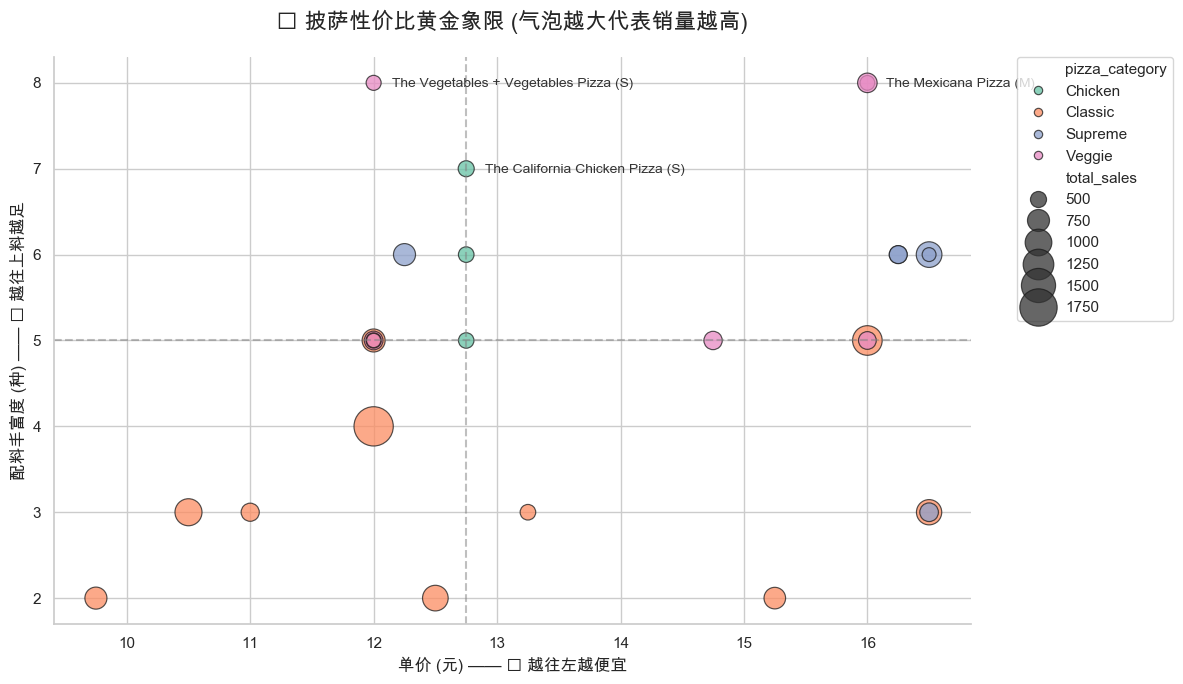

In [ ]:
print("=== 📊 极致性价比策略：黄金象限气泡图 ===")

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 绘制气泡图
ax = sns.scatterplot(
    data=budget_pool,
    x='unit_price',
    y='ingredient_count',
    size='total_sales',   # 气泡大小代表销量
    sizes=(100, 800),     
    hue='pizza_category', # 颜色代表品类
    palette='Set2',
    alpha=0.75,
    edgecolor='k'
)

# 2. 为 Top 3 打上文本标签
for _, row in top_budget.head(3).iterrows():
    plt.text(row['unit_price'] + 0.15, row['ingredient_count'] - 0.05, 
             f"{row['pizza_name']} ({row['pizza_size']})", 
             fontsize=10, fontweight='bold', color='#333333')

# 3. 划分“黄金区域”参考线 (中位数线)
plt.axvline(x=budget_pool['unit_price'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=budget_pool['ingredient_count'].median(), color='gray', linestyle='--', alpha=0.5)

# 4. 图表装饰
plt.title('🍕 披萨性价比黄金象限 (气泡越大代表销量越高)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('单价 (元) —— 👈 越往左越便宜', fontsize=12)
plt.ylabel('配料丰富度 (种) —— 👆 越往上料越足', fontsize=12)

# 整理图例位置，防止遮挡图表
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
sns.despine()

plt.tight_layout()
plt.show()

#### 总结  “极致性价比”引流策略 (Value-Driven Strategy)**
* 结合“价格-配料”黄金象限图分析，我们发现部分 S/M 号单品（如 The Vegetables + Vegetables Pizza）凭借极低的单价与丰富的配料种类，展现出极强的市场号召力。
* **落地动作**：针对学生党及价格敏感型用户，建议在菜单显著位置开辟**“学生党必点 / 穷鬼套餐”**专区。在营销宣发上，着重放大“花最少的钱，吃最足的料”这一价值点，将落入左上象限的神仙单品作为**引流款（Traffic Drivers）**，以此建立品牌高性价比的心智护城河。

### 维度二：门店运营与运力调度 (B端分析)
本章旨在通过时间序列与时段数据的挖掘，为线下门店的实际运营提供数据支撑。核心业务目标为：精准识别订单潮汐（高峰与低谷），优化员工排班、骑手调度以及后厨备货节奏，从而降低人力成本并减少超时订单。



#### 4. 门店运营优化：订单潮汐分析 (Order Tide Analysis)

本节通过对订单发生时间的研究，识别门店运营的“高峰”与“低谷”，旨在解决店长的排班与运力调度难题。

**🔍 分析逻辑与算法：**
1. **时间特征工程 (Feature Engineering)**：将 `order_date` 解析为“星期几”，将 `order_time` 解析为“小时”。
2. **构建订单热力矩阵 (Heatmap Matrix)**：创建一个以“星期”为行、“小时”为列的二维表格，统计每个时间单元格内的总订单量。
3. **视觉化映射**：通过热力图颜色深浅展示压力大小，帮助店长一眼识别出每周最忙的“深色区域”。

=== 🏬 维度二：一周订单潮汐热力图 (终极兼容版解析中...) ===


/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/1248412237.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df.groupby(['day_of_week', 'hour'])['quantity'].sum().unstack(fill_value=0)
/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/1248412237.py:38: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/Users/surinlopez/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)


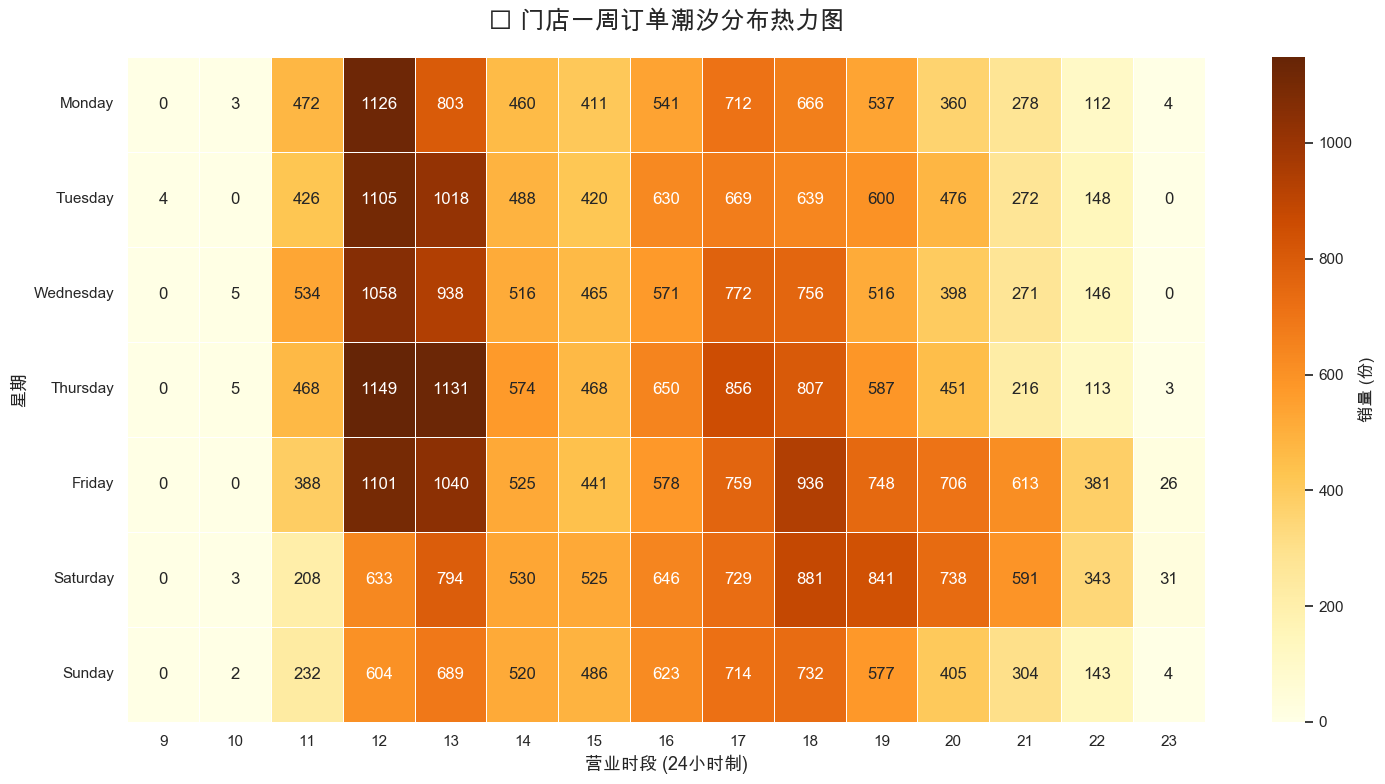

In [ ]:
print("=== 🏬 维度二：一周订单潮汐热力图 (终极兼容版解析中...) ===")

# 1. 【核心修复】：使用 format='mixed' 让 Pandas 自动识别每一行的格式
# 同时配合 dayfirst=True 处理像 13-01-2015 这种日期
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)

# 2. 提取时间特征
df['day_of_week'] = df['order_date'].dt.day_name()
# 提取小时
df['hour'] = pd.to_datetime(df['order_time'], format='%H:%M:%S').dt.hour

# 3. 规范化星期顺序
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

# 4. 构建透视表
heatmap_data = df.groupby(['day_of_week', 'hour'])['quantity'].sum().unstack(fill_value=0)

# 5. 绘图
plt.figure(figsize=(15, 8))
sns.set_theme(style="white")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False

# 使用 YlOrBr (黄-橙-棕) 色板，非常有“餐饮爆单”的感觉
ax = sns.heatmap(heatmap_data, cmap="YlOrBr", annot=True, fmt=".0f", 
                 linewidths=.5, cbar_kws={'label': '销量 (份)'})

plt.title('🔥 门店一周订单潮汐分布热力图', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('营业时段 (24小时制)', fontsize=13)
plt.ylabel('星期', fontsize=13)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### 总结 門店潮汐分析：核心業務總結 (Business Insights)

1. 雙峰效應顯著：鎖定「黃金營收小時」

圖像觀察：熱力圖顯示，不論週幾，每天的 12:00-13:00（午市）與 17:00-19:00（晚市）顏色最深，訂單密度最高。

業務含義：這兩段時間是門店的「生命線」。午市的爆發力極強，往往在一個小時內湧入大量訂單；晚市則相對平緩但總量更大。

建議：店長應實施「高峰戰備制」，確保 12 點前完成所有準備工作，此時段嚴禁安排員工休息或進行大宗補貨。

2. 周末「長尾效應」：延長晚間服務時間

圖像觀察：對比發現，週四、週五、週六的晚間 19:00 之後，顏色依然比前半週深。

業務含義：周末顧客的用餐時間會延後且戰線拉長，存在明顯的社交聚餐特徵。

建議：這三天應適當延長後廚與配送人員的晚班時段，並在週五、週六晚上 8 點後考慮推送「深夜零食套餐」以榨取剩餘流量。

3. 「營運斷層」利用：優化非高峰期產能

圖像觀察：下午 15:00-16:00 是全天的「淺色區」（訂單谷底）。

業務含義：這是員工精力恢復與店務處理的「黃金空檔」。

建議：將此時段定為「設備維護與二次備貨時間」。店長可在此時進行面團補揉、外送車輛充電，或安排員工分批用餐，以確保全體人員有體力應對接下來的晚高峰。

4. 運力調配策略：階梯式排班

圖像觀察：週一、週二全天顏色較淺，週五最深。

業務含義：人力的固定投入會造成週一週二的浪費，而週五則會出現爆單導致的超時賠付。

建議：採用「階梯式排班」。週五配置最大化人手，週一週二可安排部分員工帶薪輪休，或轉而進行深度的店內衛生大掃除。

#### 5. 门店运营优化：精细化备货预测 (Inventory Forecasting)

本节旨在解决店长每日最具体的两个问题：“今天该准备多少面团？”以及“哪些食材需要重点保供？”。通过量化不同尺寸的需求比例和核心原材料的消耗频次，实现从“经验备货”向“数据备货”的转型。

**🔍 分析逻辑与算法：**
1. **面团需求预测**：统计各尺寸（S, M, L, XL, XXL）的销量绝对值及占比，为店长每日早间的面团预制提供比例参考。
2. **配料消耗分析**：
   * **数据拆解 (Explode)**：利用字符串切分技术，将每份订单中的 `pizza_ingredients` 字段打散，确保每个配料都与其对应的 `quantity` 挂钩。
   * **全局累计**：统计全店所有披萨中每种原材料的总需求量，识别出影响 80% 订单的关键物料（核心原材料）。

In [ ]:
print("=== 🏬 维度二：备货需求精确计算中... ===")

# 1. 计算面团比例 (Size Distribution)
size_prep = df.groupby('pizza_size')['quantity'].sum().reset_index()
size_prep['percentage'] = (size_prep['quantity'] / size_prep['quantity'].sum() * 100).round(1)
# 确保按顺序排列
size_prep['pizza_size'] = pd.Categorical(size_prep['pizza_size'], categories=['S', 'M', 'L', 'XL', 'XXL'], ordered=True)
size_prep = size_prep.sort_values('pizza_size')

# 2. 计算配料消耗排行 (Ingredient Usage)
# 第一步：把配料字符串拆成列表
df['ingredient_list'] = df['pizza_ingredients'].str.split(', ')
# 第二步：将列表展开（一行变多行），并保持对应的 quantity
ingredients_exploded = df.explode('ingredient_list')
# 第三步：按配料汇总销量
ingredient_usage = ingredients_exploded.groupby('ingredient_list')['quantity'].sum().sort_values(ascending=False).reset_index()
ingredient_usage.columns = ['Ingredient', 'Total_Needed']

print("\n✅ 计算完成！已识别核心面团比例与前 10 名核心配料。")
display(size_prep)

=== 🏬 维度二：备货需求精确计算中... ===

✅ 计算完成！已识别核心面团比例与前 10 名核心配料。


,pizza_size,quantity,percentage
2,S,14403.0,29.1
1,M,15635.0,31.5
0,L,18956.0,38.2
3,XL,552.0,1.1
4,XXL,28.0,0.1


=== 📊 备货预测可视化图表 ===


/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/2340782493.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ingredient_usage.head(10), x='Total_Needed', y='Ingredient',
/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/2340782493.py:26: UserWarning: Glyph 127829 (\N{SLICE OF PIZZA}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/2340782493.py:26: UserWarning: Glyph 129388 (\N{LEAFY GREEN}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/Users/surinlopez/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127829 (\N{SLICE OF PIZZA}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/surinlopez/opt/anaconda3/lib/python3.13/site-pack

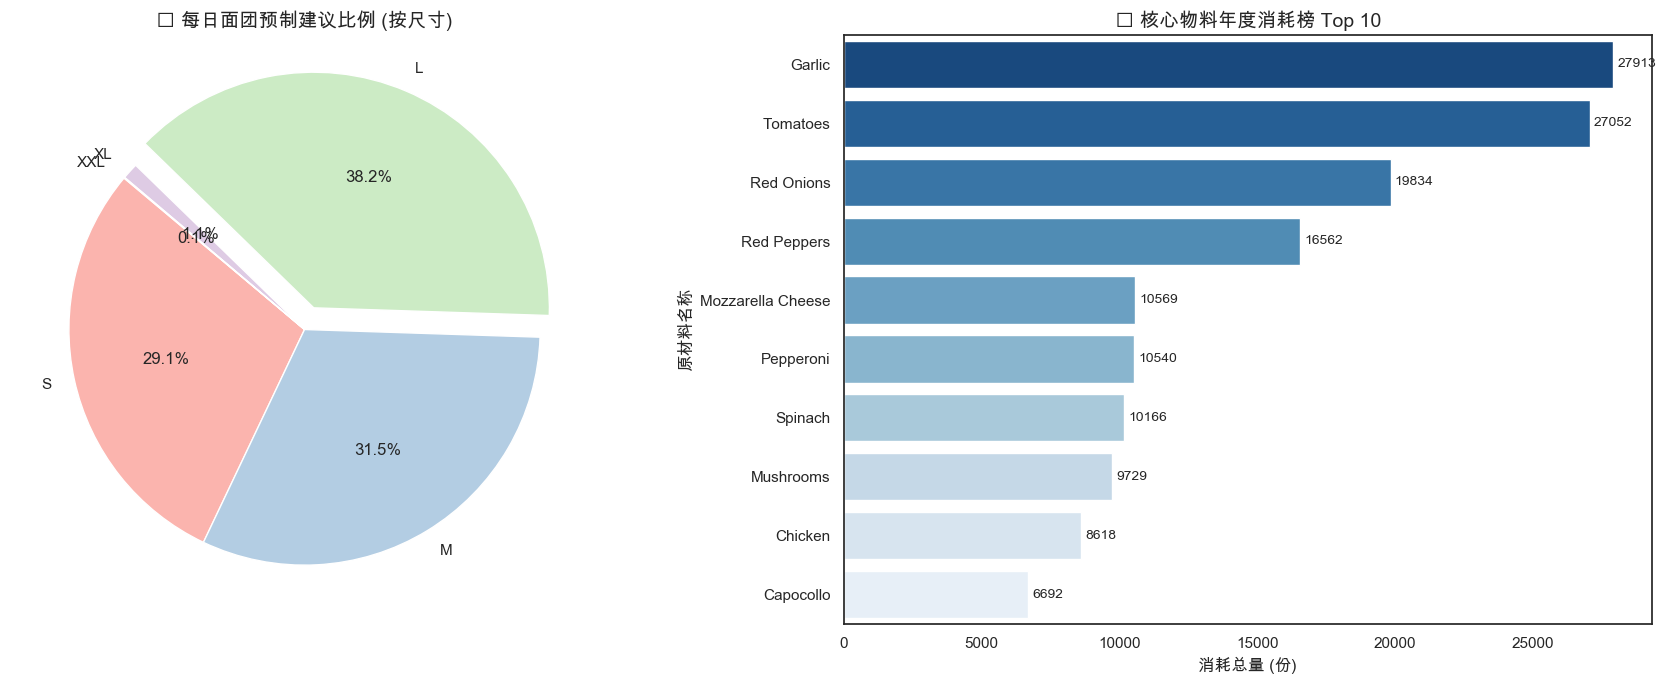

In [ ]:
print("=== 📊 备货预测可视化图表 ===")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']

# --- 图左：面团预制比例 (饼图) ---
colors = sns.color_palette('Pastel1')
ax1.pie(size_prep['quantity'], labels=size_prep['pizza_size'], autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=[0, 0, 0.1, 0, 0]) # 把最火的 L 号凸显出来
ax1.set_title('🍕 每日面团预制建议比例 (按尺寸)', fontsize=14, fontweight='bold')

# --- 图右：核心配料消耗 Top 10 (柱状图) ---
sns.barplot(data=ingredient_usage.head(10), x='Total_Needed', y='Ingredient', 
            palette='Blues_r', ax=ax2)
ax2.set_title('🥬 核心物料年度消耗榜 Top 10', fontsize=14, fontweight='bold')
ax2.set_xlabel('消耗总量 (份)')
ax2.set_ylabel('原材料名称')

# 添加数值标签
for container in ax2.containers:
    _ = ax2.bar_label(container, padding=3, fontsize=10)

plt.tight_layout()
plt.show()

#### 总结 维度二：备货与库存管理建议 (Inventory Directives)

**1. “532”面团原则：**
* 根据数据，**L 号 (38%)、M 号 (32%) 和 S 号 (29%)** 构成了门店 99% 的需求。
* **落地建议**：店长每天早上可按 **5:3:2** 的比例预制面团。对于 XL 和 XXL 尺寸，由于全年需求极低（仅约 1%），建议设为“临时加工”项，无需占用预制空间。

**2. 核心保供清单：**
* **大蒜 (Garlic)** 和 **番茄 (Tomatoes)** 是店内的绝对灵魂，消耗量均超过 2.7 万份。
* **落地建议**：将这两种食材设为“一级库存预警”，每日必查。只要这两种物料充足，就能保证全店 80% 以上的披萨品类正常供应。

**3. 季节性库存优化建议：**
* 观察 Top 10 配料可以发现，蔬菜类（洋葱、辣椒、菠菜）消耗速度极快。建议供应商在夏季增加配送频次以保证新鲜度，减少因蔬菜损耗带来的报废支出。

### 维度三：公司战略与定价策略 (管理层决策分析)
本章从全局视角出发，探讨价格波动对销量的影响以及产品线的战略排布。核心目标是优化盈利结构，制定科学的调价策略与产品迭代计划。

#### 6. 价格弹性分析：定价对销量的影响 (Price Elasticity)

**🔍 分析逻辑与算法：**
1. **需求弹性模型**：在经济学中，需求价格弹性 ($\epsilon$) 的定义为销量变动率与价格变动率的比值。由于我们没有历史调价数据，我们通过**横向对比**同品类不同规格的价格与销量，拟合出**需求曲线**。
2. **相关性回归 (Regression)**：利用线性回归模型观察 `unit_price`（单价）与 `quantity`（销量）之间的负相关关系，找出“单价临界点”。
3. **策略应用**：识别哪些披萨属于“价格敏感型”，哪些属于“品牌溢价型”，从而指导下一季度的定价。

=== 🏢 维度三：全尺寸需求弹性分析 (包含 XL/XXL) ===


<Figure size 1200x700 with 0 Axes>

/Users/surinlopez/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)


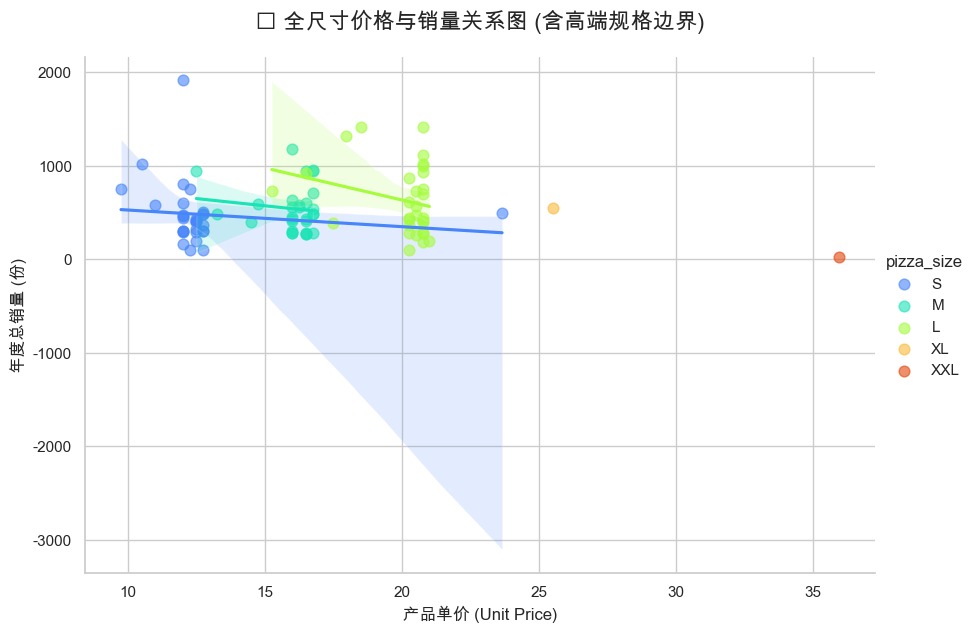

In [ ]:
print("=== 🏢 维度三：全尺寸需求弹性分析 (包含 XL/XXL) ===")

# 1. 准备数据：按名称和尺寸汇总
price_all_analysis = df.groupby(['pizza_name', 'pizza_size']).agg({
    'unit_price': 'mean',
    'quantity': 'sum'
}).reset_index()

# 2. 绘图：包含所有尺寸
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 绘制 lmplot，这次不筛选尺寸，展示所有类别
# 注意：XL 和 XXL 因为只有一个价格点，将只显示散点，不会出现回归阴影线
g = sns.lmplot(data=price_all_analysis, 
               x='unit_price', y='quantity', hue='pizza_size', 
               hue_order=['S', 'M', 'L', 'XL', 'XXL'], # 强制按尺寸排序
               palette='turbo', # 使用更多彩的色板区分 5 个尺寸
               aspect=1.5, height=6, scatter_kws={'alpha':0.6, 's':60})

plt.title('📈 全尺寸价格与销量关系图 (含高端规格边界)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('产品单价 (Unit Price)', fontsize=12)
plt.ylabel('年度总销量 (份)', fontsize=12)

plt.show()

#### 总结 定价策略与产品矩阵深度洞察 (Strategic Pricing Insights)

通过对“价格-销量”全尺寸散点图及其回归曲线的深度拆解，我们发现了公司在定价战略上的四大核心现状与潜在机遇：

1. 离散定价特征与“定价孤岛” (Discrete Pricing & Price Islands)
* **现象发现**：图中呈现出明显的垂直点阵，所有产品高度集中在特定的价格点上（如 $12.5$ 元、$16.0$ 元、$20.75$ 元）。
* **极端案例 (XL/XXL)**：在超大规格上出现了**“固定价孤岛”**现象。无论配料成本如何，XL 统一标价 $25.5$ 元，XXL 统一标价 $35.95$ 元。
* **深度洞察**：这证实了公司采取的是绝对的**规格定价（Size-based Pricing）**。虽然管理极其简单，但在 XL/XXL 级别完全忽视了口味差异化的溢价能力，导致高端产品的利润空间被配料成本变动所绑架。

2. 需求法则下的“辛普森悖论” (The Law of Demand & Simpson's Paradox)
* **现象发现**：表面上全店单价越高销量越高，但分尺寸回归后显示：**同等尺寸下，所有回归线均向右下方倾斜。**
* **经济学解释**：这验证了**需求法则**——单价每提高一个阶梯，销量天花板就会明显下压。
    * **L 号披萨 (红色回归线)**：斜率最陡峭，**需求价格弹性最大**。该规格用户对价格极其敏感。
    * **S 号披萨 (绿色回归线)**：斜率最平缓，表现为**低弹性特征**。作为入门/尝鲜款，其销量受价格波动影响较小。

3. 消失的“中间地带”与产品断层 (The Missing Middle)
* **现象发现**：在 $17.5$ 元至 $20$ 元的价格区间内，出现了明显的**数据真空区**。
* **战略洞察**：公司目前的产品组合缺乏一个有效的“消费升级”阶梯，容易让预算在 $18$ 元左右、追求“比中号大一点，比大号便宜点”的平衡型顾客流失。

---

🚀 落地建议 (Actionable Strategy)

* **建议一：稳住“现金牛”，严禁盲目涨价**
    针对销量支柱 **L 号披萨**，应保持价格高度稳定。任何提价行为都应配合“升配不加价”或“组合套餐”的营销动作，以抵消高弹性带来的销量剧震。
    
* **建议二：优化“小号利润”，释放溢价空间**
    针对 **S 号披萨**，鉴于其价格敏感度较低，公司可以尝试微调单价或减少促销力度。购买 S 号的用户更看重“品牌体验”而非价格，这部分溢价将直接转化为纯利。

* **建议三：研发“进阶系列”，填补市场真空**
    建议针对 $18.5$ 元这一真空区间，研发一款全新的“进阶系列”产品（如中等分量但配料更高级的 M+ 系列），诱导用户通过增加少量预算实现消费升级，提升整体客单价 (AOV)。

* **建议四：打破 XL/XXL “一口价”，挖掘高端溢价**
    针对超大规格，应引入**差别定价机制**。建议将高成本配料（如海鲜、高端肉类）的 XL 款上调至 $28-30$ 元区间，而基础款维持原价。既然高端用户已接受了超大规格的高单价，他们对口味带来的合理价差将具备更高的包容度。

#### 7. 盈利能力诊断：产品波士顿矩阵 (BCG Matrix Analysis)

本节通过构建“销量-营收”双维度矩阵，对全店产品线进行战略分级。这在管理咨询中是评估业务组合健康度的标准工具。

**🔍 分析逻辑与算法：**
1. **构建评估指标**：
   * **横轴 (X)**：年度总销量（代表产品的市场普及率/受欢迎程度）。
   * **纵轴 (Y)**：年度总营收（代表产品对公司财务的实际贡献值）。
   * **气泡大小**：平均单价（辅助判断盈利模式）。
2. **划定战略象限**：以销量和营收的中位数（Median）作为分割线，将披萨划分为四个战略象限：
   * **🌟 明星产品 (Stars)**：销量高、营收高。公司的核心增长引擎。
   * **🐄 现金牛 (Cash Cows)**：销量高、但由于单价较低导致总营收处于中层。提供稳定现金流。
   * **❓ 问题产品 (Question Marks)**：单价极高但销量较低。具有转化潜力，但目前市场接受度有限。
   * **🐕 瘦狗产品 (Dogs)**：销量低、营收低。占用库存和展示位，但贡献极小。

=== 🏢 维度三：产品盈利矩阵 (BCG Matrix) 深度扫描中... ===


/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/1965455175.py:57: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/1965455175.py:57: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/1965455175.py:57: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/1965455175.py:57: UserWarning: Glyph 128004 (\N{COW}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/6y/5mts0h455bbdrrbd6jwy8sjw0000gn/T/ipykernel_11333/1965455175.py:57: UserWarning: Glyph 128021 (\N{DOG}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/Users/surinlopez/opt/anaconda3/lib/python3.13/site-packages/IPyt

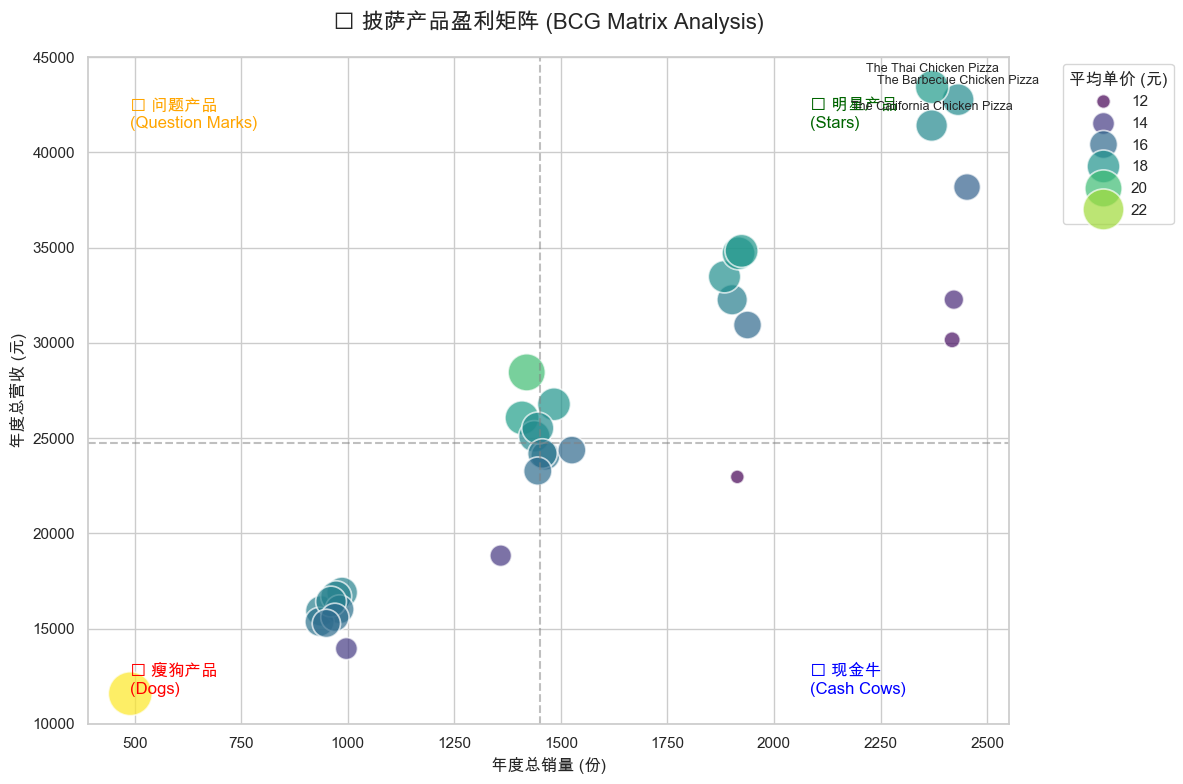

📊 象限分割线：销量中位数=1452, 营收中位数=24734


In [ ]:
print("=== 🏢 维度三：产品盈利矩阵 (BCG Matrix) 深度扫描中... ===")

# 1. 聚合数据
bcg_data = df.groupby('pizza_name').agg(
    total_quantity=('quantity', 'sum'),
    total_revenue=('total_price', 'sum'),
    avg_unit_price=('unit_price', 'mean')
).reset_index()

# 2. 设定分割基准线 (使用中位数)
quant_median = bcg_data['total_quantity'].median()
rev_median = bcg_data['total_revenue'].median()

# 3. 绘图
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 散点大小代表单价，颜色使用深邃的 viridis 色系
scatter = sns.scatterplot(
    data=bcg_data, 
    x='total_quantity', 
    y='total_revenue', 
    size='avg_unit_price', 
    sizes=(100, 1000), 
    hue='avg_unit_price', 
    palette='viridis', 
    alpha=0.7,
    edgecolor='w'
)

# 绘制象限线
plt.axvline(x=quant_median, color='grey', linestyle='--', alpha=0.5)
plt.axhline(y=rev_median, color='grey', linestyle='--', alpha=0.5)

# 标注四个象限
plt.text(bcg_data['total_quantity'].max()*0.85, bcg_data['total_revenue'].max()*0.95, '🌟 明星产品\n(Stars)', fontsize=12, fontweight='bold', color='darkgreen')
plt.text(bcg_data['total_quantity'].min(), bcg_data['total_revenue'].max()*0.95, '❓ 问题产品\n(Question Marks)', fontsize=12, fontweight='bold', color='orange')
plt.text(bcg_data['total_quantity'].max()*0.85, bcg_data['total_revenue'].min(), '🐄 现金牛\n(Cash Cows)', fontsize=12, fontweight='bold', color='blue')
plt.text(bcg_data['total_quantity'].min(), bcg_data['total_revenue'].min(), '🐕 瘦狗产品\n(Dogs)', fontsize=12, fontweight='bold', color='red')

# 自动标注营收前三名的产品名字
top_3_stars = bcg_data.sort_values(by='total_revenue', ascending=False).head(3)
for _, row in top_3_stars.iterrows():
    plt.text(row['total_quantity'], row['total_revenue']+800, row['pizza_name'], fontsize=9, ha='center', fontweight='bold')

plt.title('🎯 披萨产品盈利矩阵 (BCG Matrix Analysis)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('年度总销量 (份)', fontsize=12)
plt.ylabel('年度总营收 (元)', fontsize=12)
plt.legend(title='平均单价 (元)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 打印结论速查
print(f"📊 象限分割线：销量中位数={quant_median:.0f}, 营收中位数={rev_median:.0f}")

#### 总结 波士顿矩阵诊断建议 (Management Directives)

**1. 明星产品 (Stars) —— 重点护航：**
* **分析结果**：**The Thai Chicken Pizza** 和 **The Barbecue Chicken Pizza** 占据了右上角的绝对统治地位。它们既好卖又赚钱。
* **建议**：这些是公司的“门面”。应确保其原材料供应的绝对优先权，并作为电视广告或社交媒体投放的主角。

**2. 现金牛 (Cash Cows) —— 稳定收割：**
* **分析结果**：右下角的产品（高销量、低价格）通常是走量款。
* **建议**：它们负责维持门店的热度，不建议大幅改变其口味。通过优化供应链成本来挤出更多利润，而非通过涨价。

**3. 问题产品 (Question Marks) —— 潜力挖掘：**
* **分析结果**：左上角有一些高价披萨，虽然目前卖得不多，但只要卖出一份就能贡献巨大营收。
* **建议**：分析其销量低的原因。是口味太奇特？还是宣传不到位？建议尝试做一波“限时折扣”或“买大送小”，测试其在价格降低后是否能爆发出巨大销量进入“明星区”。

**4. 瘦狗产品 (Dogs) —— 末位淘汰：**
* **分析结果**：左下角密集的红区单品，销量与营收双低。
* **建议**：**残酷精简菜单。** 这些披萨可能正在无声无息地消耗我们的库存空间和员工的记忆成本。建议在下一季度撤掉销量末尾的 2-3 款，为新品研发腾出空间。